In [2]:
pip install fiona matplotlib numpy pandas geopandas rasterio rasterstats shapely earthengine-api geemap

Note: you may need to restart the kernel to use updated packages.


In [3]:
import fiona
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely.affinity as affinity
import rasterio
from rasterstats import zonal_stats
import ee
import geemap

In [4]:
file_path = r"D:\Shapefiles\ACZ\ACZ_1.shp"
gdf = gpd.read_file(file_path)
gdf.head()

,OBJECTID_1,STATE_UT,STATE_LGD,DISTRICT,DIST_LGD,SUB_DIST,SUBDIS_LGD,SUBDIS_TYP,REMARKS,Shape_Leng,Shape_Area,geometry
0,1917,GUJARAT,24,BANAS KANTHA,469,AMIRGADH,3736,Taluk,None,152225.912791,6.634382e+08,"POLYGON ((3258894.297 4076037.549, 3258912.233..."
1,1931,GUJARAT,24,ARVALLI,650,BAYAD,3772,Taluk,None,190231.227506,5.725048e+08,"POLYGON ((3305316.409 3937008.914, 3305372.914..."
2,1932,GUJARAT,24,MAHESANA,471,BECHARAJI,3758,Taluk,None,148742.901196,3.971164e+08,"POLYGON ((3225585.411 3982779.193, 3225628.063..."
3,1933,GUJARAT,24,BANAS KANTHA,469,BHABHAR,3742,Taluk,None,128525.709802,4.160731e+08,"POLYGON ((3168100.015 4048282.998, 3168157.35 ..."
4,1939,GUJARAT,24,ARVALLI,650,BHILODA,3764,Taluk,None,185307.180838,6.095085e+08,"POLYGON ((3337159.53 4005825.8, 3337185.051 40..."


In [5]:
print(gdf.columns)

Index(['OBJECTID_1', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD',
       'SUB_DIST', 'SUBDIS_LGD', 'SUBDIS_TYP', 'REMARKS', 'Shape_Leng',
       'Shape_Area', 'geometry'],
      dtype='object')


In [6]:
print(gdf['DISTRICT'].unique())

['BANAS KANTHA' 'ARVALLI' 'MAHESANA' 'PATAN' 'GANDHINAGAR' 'SABAR KANTHA']


In [7]:
print(gdf['SUB_DIST'].unique())

['AMIRGADH' 'BAYAD' 'BECHARAJI' 'BHABHAR' 'BHILODA' 'CHANASMA' 'DANTA'
 'DANTIWADA' 'DEESA' 'DEHGAM' 'DEODAR' 'DHANERA' 'DHANSURA' 'GANDHINAGAR'
 'HARIJ' 'HIMATNAGAR' 'IDAR' 'JOTANA' 'KADI' 'KALOL' 'KANKREJ'
 'KHEDBRAHMA' 'KHERALU' 'LAKHANI' 'MAHESANA' 'MALPUR' 'MANSA' 'MEGHRAJ'
 'MODASA' 'PALANPUR' 'PATAN' 'POSHINA' 'PRANTIJ' 'RADHANPUR' 'SAMI'
 'SANTALPUR' 'SARASWATI' 'SATLASANA' 'SHANKHESHWAR' 'SIDHPUR' 'SUIGAM'
 'TALOD' 'THARAD' 'UNJHA' 'VADALI' 'VADGAM' 'VADNAGAR' 'VAV' 'VIJAPUR'
 'VIJAYNAGAR' 'VISNAGAR']


In [8]:
print(gdf[gdf['DISTRICT'] == "MAHESANA"]['SUB_DIST'].unique())

['BECHARAJI' 'JOTANA' 'KADI' 'KHERALU' 'MAHESANA' 'SATLASANA' 'UNJHA'
 'VADNAGAR' 'VIJAPUR' 'VISNAGAR']


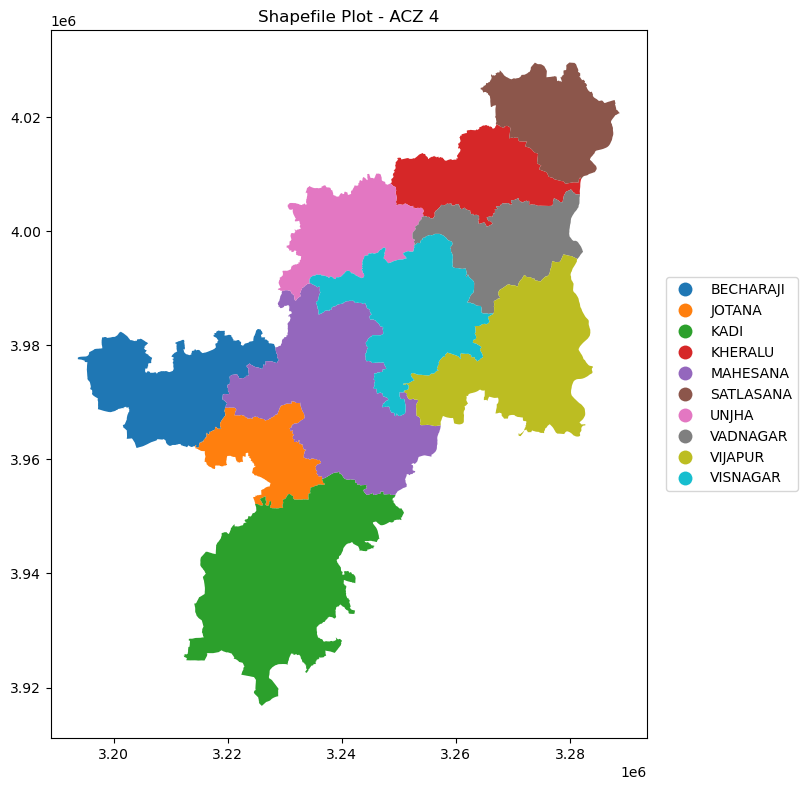

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf[gdf['DISTRICT'] == 'MAHESANA'].plot(
    column='SUB_DIST',
    legend=True,
    ax=ax,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1.02, 0.5)
    }
)

ax.set_title("Shapefile Plot - ACZ 4")
plt.tight_layout()
plt.show()


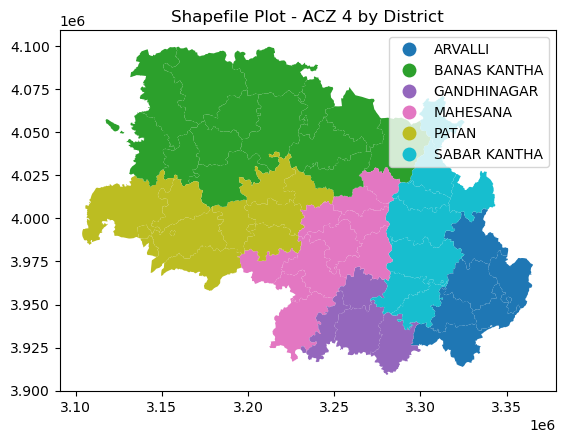

In [37]:
gdf.plot(column='DISTRICT', legend=True)
plt.title("Shapefile Plot - ACZ 4 by District")
plt.show()

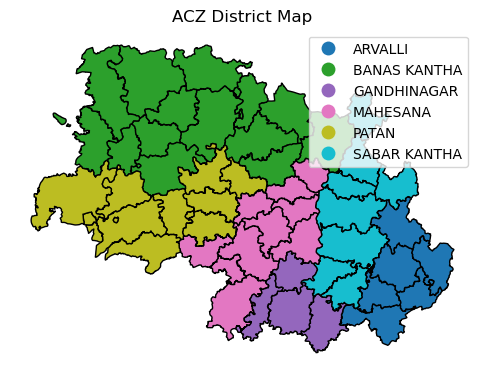

In [74]:
fig,ax = plt.subplots(figsize=(6,6))
gdf.plot(column='DISTRICT',legend=True,ax=ax,edgecolor='black')
ax.set_title('ACZ District Map')
ax.axis('off')
plt.show()

In [38]:
print(gdf.crs)

PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [75]:
gdf = gdf.to_crs(epsg=32643)

In [76]:
gdf["calc_area_sqm"] = gdf.geometry.area
gdf["calc_area_sqkm"]= gdf["calc_area_sqm"] / 1_000_000
district_area = (
    gdf.groupby("DISTRICT")["calc_area_sqkm"].sum().reset_index()
)
print(district_area)

       DISTRICT  calc_area_sqkm
0       ARVALLI     3163.070467
1  BANAS KANTHA    10779.826835
2   GANDHINAGAR     2103.945483
3      MAHESANA     4422.420441
4         PATAN     5796.551562
5  SABAR KANTHA     4229.980431


In [77]:
gdf["shape_area_sqkm"] = gdf["Shape_Area"] / 1_000_000

compare = (
    gdf
    .groupby("DISTRICT")[["calc_area_sqkm", "shape_area_sqkm"]]
    .sum()
    .reset_index()
)

compare["difference_sqkm"] = (
    compare["calc_area_sqkm"] - compare["shape_area_sqkm"]
)

print(compare)


       DISTRICT  calc_area_sqkm  shape_area_sqkm  difference_sqkm
0       ARVALLI     3163.070467      3041.654622       121.415845
1  BANAS KANTHA    10779.826835     10349.019411       430.807425
2   GANDHINAGAR     2103.945483      2021.995152        81.950330
3      MAHESANA     4422.420441      4248.515166       173.905274
4         PATAN     5796.551562      5562.451842       234.099720
5  SABAR KANTHA     4229.980431      4066.260061       163.720370


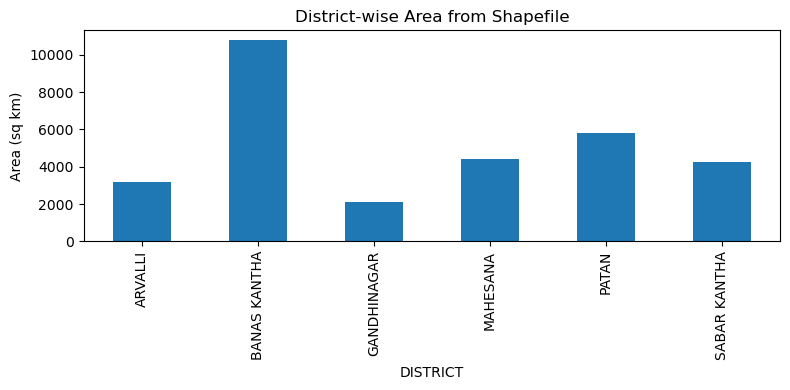

In [62]:
district_area.plot(
    x="DISTRICT",
    y="calc_area_sqkm",
    kind="bar",
    legend=False,
    figsize=(8,4)
)

plt.ylabel("Area (sq km)")
plt.title("District-wise Area from Shapefile")
plt.tight_layout()
plt.show()


In [63]:
district_dissolved = gdf.dissolve(by="DISTRICT")

district_dissolved["area_sqkm"] = (
    district_dissolved.geometry.area / 1_000_000
)

print(district_dissolved[["area_sqkm"]])


                 area_sqkm
DISTRICT                  
ARVALLI        3041.654622
BANAS KANTHA  10349.019411
GANDHINAGAR    2021.995152
MAHESANA       4248.515166
PATAN          5562.451842
SABAR KANTHA   4066.260061


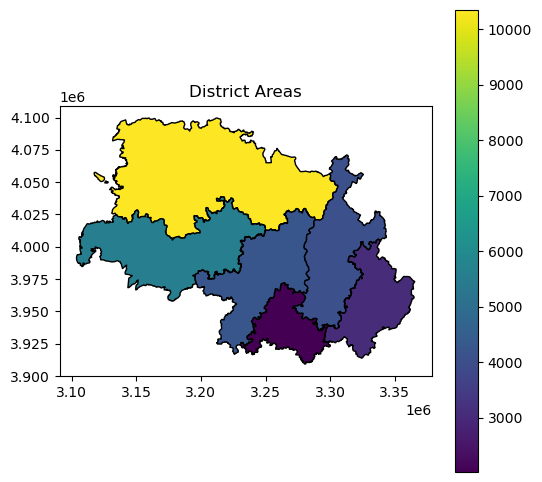

In [66]:
district_dissolved.plot(
    column="area_sqkm",
    legend=True,
    edgecolor="black",
    figsize=(6,6)
)

plt.title("District Areas")
plt.show()


        SUB_DIST    area_sqkm
0       AMIRGADH   690.480884
1          BAYAD   595.367357
2      BECHARAJI   413.576079
3        BHABHAR   433.696595
4        BHILODA   633.893285
5       CHANASMA   457.931102
6          DANTA   902.701812
7      DANTIWADA   445.270286
8          DEESA  1076.227076
9         DEHGAM   589.771935
10        DEODAR   510.602614
11       DHANERA   834.270930
12      DHANSURA   399.471196
13   GANDHINAGAR   673.887631
14         HARIJ   459.510884
15    HIMATNAGAR   853.466907
16          IDAR   811.118618
17        JOTANA   215.090827
18          KADI   787.188055
19         KALOL   410.756907
20       KANKREJ   850.339713
21    KHEDBRAHMA   502.128819
22       KHERALU   320.129606
23       LAKHANI   569.816119
24      MAHESANA   691.882972
25        MALPUR   366.076003
26         MANSA   429.529009
27       MEGHRAJ   551.430108
28        MODASA   616.832517
29      PALANPUR   807.614367
30         PATAN   469.145975
31       POSHINA   389.042153
32       P

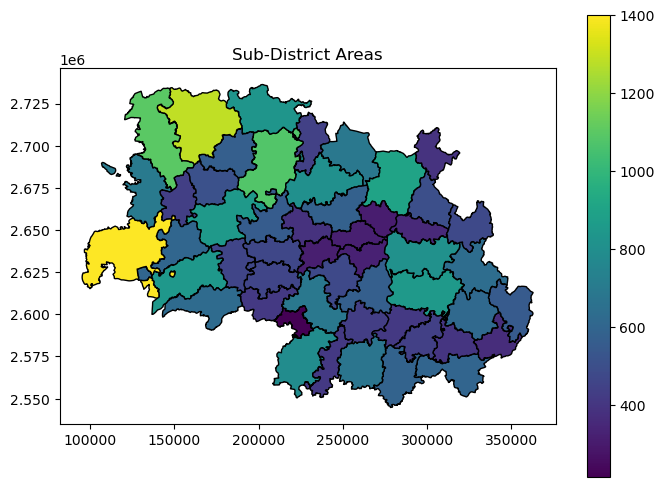

In [83]:
subdist_gdf = gdf.dissolve(by="SUB_DIST").reset_index()
subdist_gdf['area_sqkm'] = subdist_gdf.geometry.area / 1_000_000
print(subdist_gdf[["SUB_DIST", "area_sqkm"]])
subdist_gdf.plot(
    column="area_sqkm",
    legend=True,
    edgecolor="black",
    figsize=(8,6)
)
plt.title("Sub-District Areas")
plt.show()

In [84]:
subdist_gdf = (gdf.dissolve(by='SUB_DIST',aggfunc='first').reset_index())

In [141]:
print(subdist_gdf.columns)
print('-'*10)
print(gdf.columns)
print('-'*10)
print(set.difference(set(gdf.columns), set(subdist_gdf.columns)))

Index(['SUB_DIST', 'DISTRICT', 'STATE_UT', 'geometry', 'area_sqkm'], dtype='object')
----------
Index(['OBJECTID_1', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD',
       'SUB_DIST', 'SUBDIS_LGD', 'SUBDIS_TYP', 'REMARKS', 'Shape_Leng',
       'Shape_Area', 'geometry', 'calc_area_sqm', 'calc_area_sqkm',
       'shape_area_sqkm'],
      dtype='object')
----------
{'DIST_LGD', 'STATE_LGD', 'SUBDIS_TYP', 'REMARKS', 'calc_area_sqm', 'SUBDIS_LGD', 'calc_area_sqkm', 'OBJECTID_1', 'Shape_Area', 'shape_area_sqkm', 'Shape_Leng'}


In [142]:
subdist_gdf = subdist_gdf[['SUB_DIST','DISTRICT','STATE_UT','geometry']].copy()
subdist_gdf['area_sqkm']=subdist_gdf.geometry.area/1_000_000

In [143]:
field_coordinates_path = r"D:\Shapefiles\Yield_Prediction_ENR_704\farm_coordinates.csv"
farms = pd.read_csv(field_coordinates_path)
print(farms.head())
print(farms.columns)
print(len(farms))


   id   latitude  longitude
0   1  23.814944  72.720782
1   2  23.814771  72.717000
2   3  23.810884  72.712770
3   4  23.813983  72.713893
4   5  23.816433  72.718299
Index(['id', 'latitude', 'longitude'], dtype='object')
25


In [144]:
ee.Authenticate()
ee.Initialize()

In [145]:
features = []
for _,row in farms.iterrows():
    point = ee.Geometry.Point(row['longitude'], row['latitude'])
    feat = ee.Feature(point,{"class":1})
    features.append(feat)

wheat_fc = ee.FeatureCollection(features)
print(wheat_fc.size().getInfo())

25


In [146]:
shp = ee.FeatureCollection('projects/igarss-2026/assets/Gujarat_ACZ_1')
print(shp.size().getInfo())

51


In [147]:
roi = shp.geometry()
start = '2025-11-15'
end = '2026-04-15'

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(roi)
    .filterDate(start,end)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE",20))
)

print(s2.size().getInfo())

370


In [148]:
last = s2.sort("system:time_start",False).first()
second_last = ee.Image(s2.sort("system:time_start",False).toList(4).get(2))
print(ee.Date(last.get("system:time_start")).format().getInfo())

2026-02-05T05:52:46


In [149]:
def add_date(img):
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")
    return img.set("date", date)
s2_with_date = s2.map(add_date)
unique = s2_with_date.distinct('date')
print(unique.aggregate_array('date').getInfo())

['2025-11-15', '2025-11-17', '2025-11-20', '2025-11-22', '2025-11-25', '2025-11-27', '2025-11-29', '2025-12-02', '2025-12-05', '2025-12-07', '2025-12-10', '2025-12-12', '2025-12-15', '2025-12-17', '2025-12-19', '2025-12-20', '2025-12-22', '2025-12-25', '2025-12-27', '2025-12-30', '2026-01-01', '2026-01-04', '2026-01-06', '2026-01-08', '2026-01-09', '2026-01-11', '2026-01-14', '2026-01-16', '2026-01-19', '2026-01-21', '2026-01-24', '2026-01-29', '2026-01-31', '2026-02-03', '2026-02-05']


In [150]:
tiles = s2.aggregate_array('MGRS_TILE').distinct()
print(f'Tiles covering ROI: {tiles.getInfo()}\n Number of Tiles: {tiles.size().getInfo()}')

Tiles covering ROI: ['42QXM', '42QYL', '42QYM', '42QZL', '42QZM', '42RYN', '42RZN', '43QBF', '43QBG', '43RBH', '43QCF', '43QCG', '43RCH']
 Number of Tiles: 13


In [152]:
def tile_to_feature(tile):
    tile = ee.String(tile)

    img = s2.filter(ee.Filter.eq("MGRS_TILE", tile)).first()

    return ee.Feature(img.geometry(), {"tile": tile})

tile_fc = ee.FeatureCollection(tiles.map(tile_to_feature))


In [153]:
print("Image count per date example:")
print(
    s2_with_date
    .filter(ee.Filter.eq("date", "2026-02-05"))
    .size()
    .getInfo()
)


Image count per date example:
12


In [155]:
def tile_to_feature(tile):
    tile = ee.String(tile)

    img = s2.filter(ee.Filter.eq("MGRS_TILE", tile)).first()

    # use bounding box instead of full geometry
    geom = img.geometry().bounds()

    return ee.Feature(geom, {"tile": tile})

tile_fc = ee.FeatureCollection(tiles.map(tile_to_feature))
print("tile_fc ready")


tile_fc ready


In [156]:
def add_ndvi(img):
    ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
    return img.addBands(ndvi)

s2_ndvi = s2.map(add_ndvi)
ndvi_img = s2_ndvi.select('NDVI').median().clip(roi)
print('NDVI image ready')

NDVI image ready


In [158]:
roi = shp.union().geometry()
def add_ndvi(img):
    ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
    return img.addBands(ndvi)
s2_ndvi = s2.map(add_ndvi)
ndvi_img = s2_ndvi.select('NDVI').median().clip(roi)
print('NDVI image ready',ndvi_img.bandNames().getInfo())

NDVI image ready ['NDVI']


In [159]:
sample = ndvi_img.sampleRegions(
    collection=wheat_fc,
    scale=10,
    geometries=True 
)

print(sample.size().getInfo())
print(sample.first().getInfo())

25
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [72.72082312192136, 23.81492208694319]}, 'id': '0_0', 'properties': {'NDVI': 0.4453427195549011, 'class': 1}}


In [160]:
print(wheat_fc.first().getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [72.720782, 23.814944]}, 'id': '0', 'properties': {'class': 1}}


In [161]:
print(roi.getInfo())

{'type': 'GeometryCollection', 'geometries': [{'type': 'LineString', 'coordinates': [[73.15434696479063, 23.498544185922448], [73.15435101440669, 23.498467377421925]]}, {'type': 'Polygon', 'coordinates': [[[71.2239412825572, 24.20472026921036], [71.23484347216699, 24.202838684789302], [71.24060696908774, 24.206268058379013], [71.24197876431346, 24.21305512687944], [71.23504595919837, 24.209929962169934], [71.23120358190637, 24.213497526644563], [71.230056444654, 24.215020961821725], [71.22456897352673, 24.218398253976012], [71.21823591006756, 24.209028164917346], [71.2162791103325, 24.204474172471393], [71.2239412825572, 24.20472026921036]]]}, {'type': 'Polygon', 'coordinates': [[[71.13120803795627, 24.26219147310398], [71.131760446009, 24.257790426376904], [71.13500534055684, 24.252583138441878], [71.13766353964049, 24.249297458806993], [71.13956334328643, 24.250799350698703], [71.14759826542696, 24.245144829393375], [71.15122379545885, 24.241511662512675], [71.15988083684984, 24.2356

In [162]:
print(ndvi_img.bandNames().getInfo())

['NDVI']


In [163]:
non_wheat = ndvi_img.sample(
    region = roi,
    scale = 10,
    numPixels = 300,
    geometries = True
)
non_wheat = non_wheat.map(lambda f: f.set("class",0))
print('Non-wheat samples:',non_wheat.size().getInfo())

Non-wheat samples: 300


In [164]:
wheat_polygons = wheat_fc.map(lambda f:f.buffer(200))
print(wheat_polygons.size().getInfo())

25


In [167]:
wheat_pixels = ndvi_img.sampleRegions(
    collection = wheat_polygons,
    scale=10,
    geometries = True
)
wheat_pixels = wheat_pixels.map(lambda f:f.set('class',1))
print('Wheat samples:',wheat_pixels.size().getInfo())
wheat_pixels_small = wheat_pixels.limit(5000)
print('Wheat used:',wheat_pixels_small.size().getInfo())

Wheat samples: 33966
Wheat used: 5000


In [169]:
non_wheat = ndvi_img.sample(
    region = roi,
    scale=10,
    numPixels = 5000,
    geometries=False,
    tileScale=4
)
non_wheat = non_wheat.map(lambda f:f.set('class',0))
print('Non-wheat samples:',non_wheat.size().getInfo())

EEException: Computation timed out.

In [ ]:
training_fc = wheat_pixels_small.merge(non_wheat)
print('Total training samples:',training_fc.size().getInfo())